# Experiment 1: Cats, Dogs, Cars

Baseline experiment on three well-defined ImageNet classes. We examine PCA subspace geometry, inter- and intra-class distances (Euclidean, Cosine, Mahalanobis), KL divergence over activation distributions, and top-5 prediction distributions.

## Data Check

In [11]:
import os

base_path = "/Users/jaeeponde/Thesis/Data_100"

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff", ".webp")

for subfolder in sorted(os.listdir(base_path)):
    subfolder_path = os.path.join(base_path, subfolder)
    
    if os.path.isdir(subfolder_path):
        count = sum(
            1 for file in os.listdir(subfolder_path)
            if file.lower().endswith(image_extensions)
        )
        
        print(f"{subfolder}: {count} images")

Cars: 221 images
Cats: 202 images
Dogs: 314 images
Memes: 6991 images
Microscopy: 465 images
Rangoli: 358 images


## PCA 3D and Activation Histograms

Loading models...


/Users/jaeeponde/anaconda3/envs/kcdha/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/jaeeponde/anaconda3/envs/kcdha/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/Users/jaeeponde/anaconda3/envs/kcdha/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`

Models ready.

Loaded: Cats
Loaded: Dogs
Loaded: Cars

ResNet features:    (300, 2048)
MobileNet features: (300, 1280)

ResNet PCA 3D explained variance:    0.330
MobileNet PCA 3D explained variance: 0.263


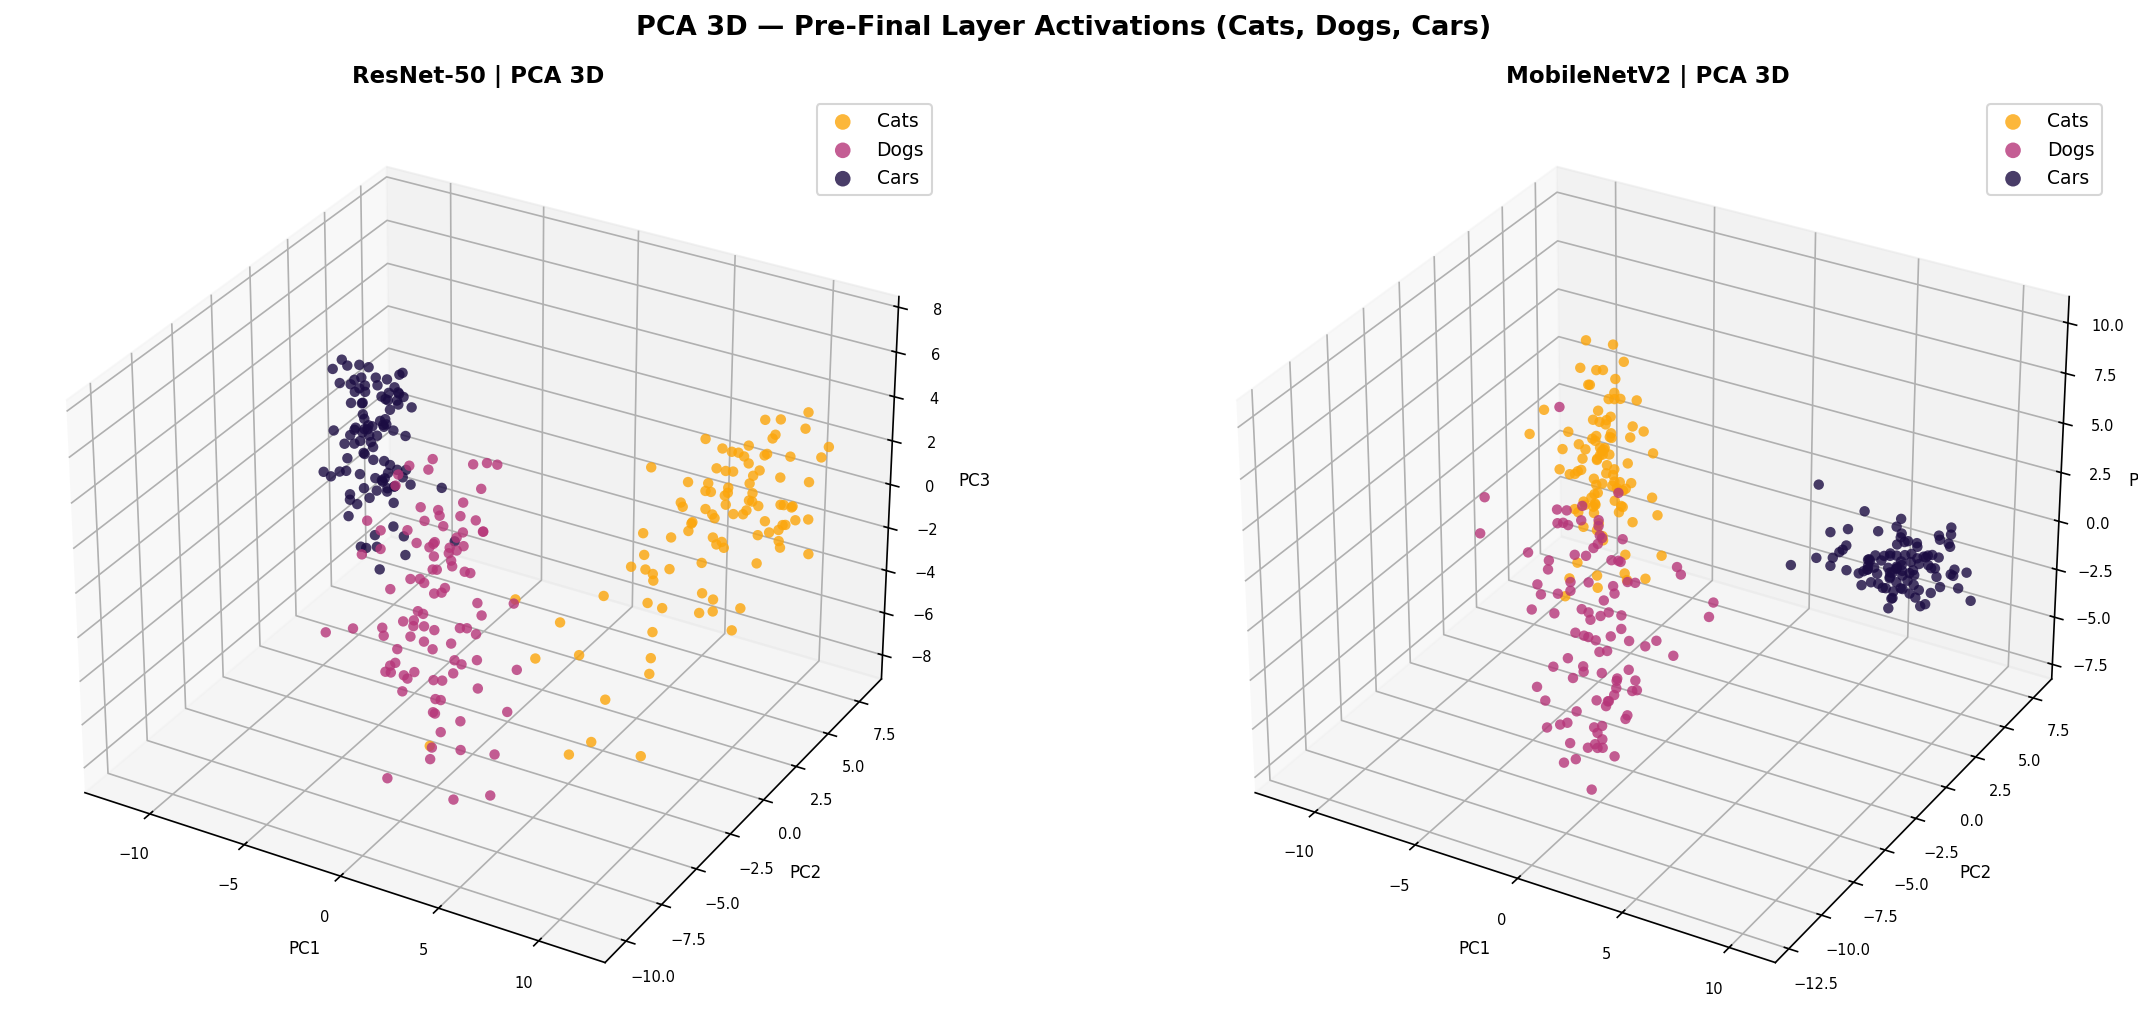

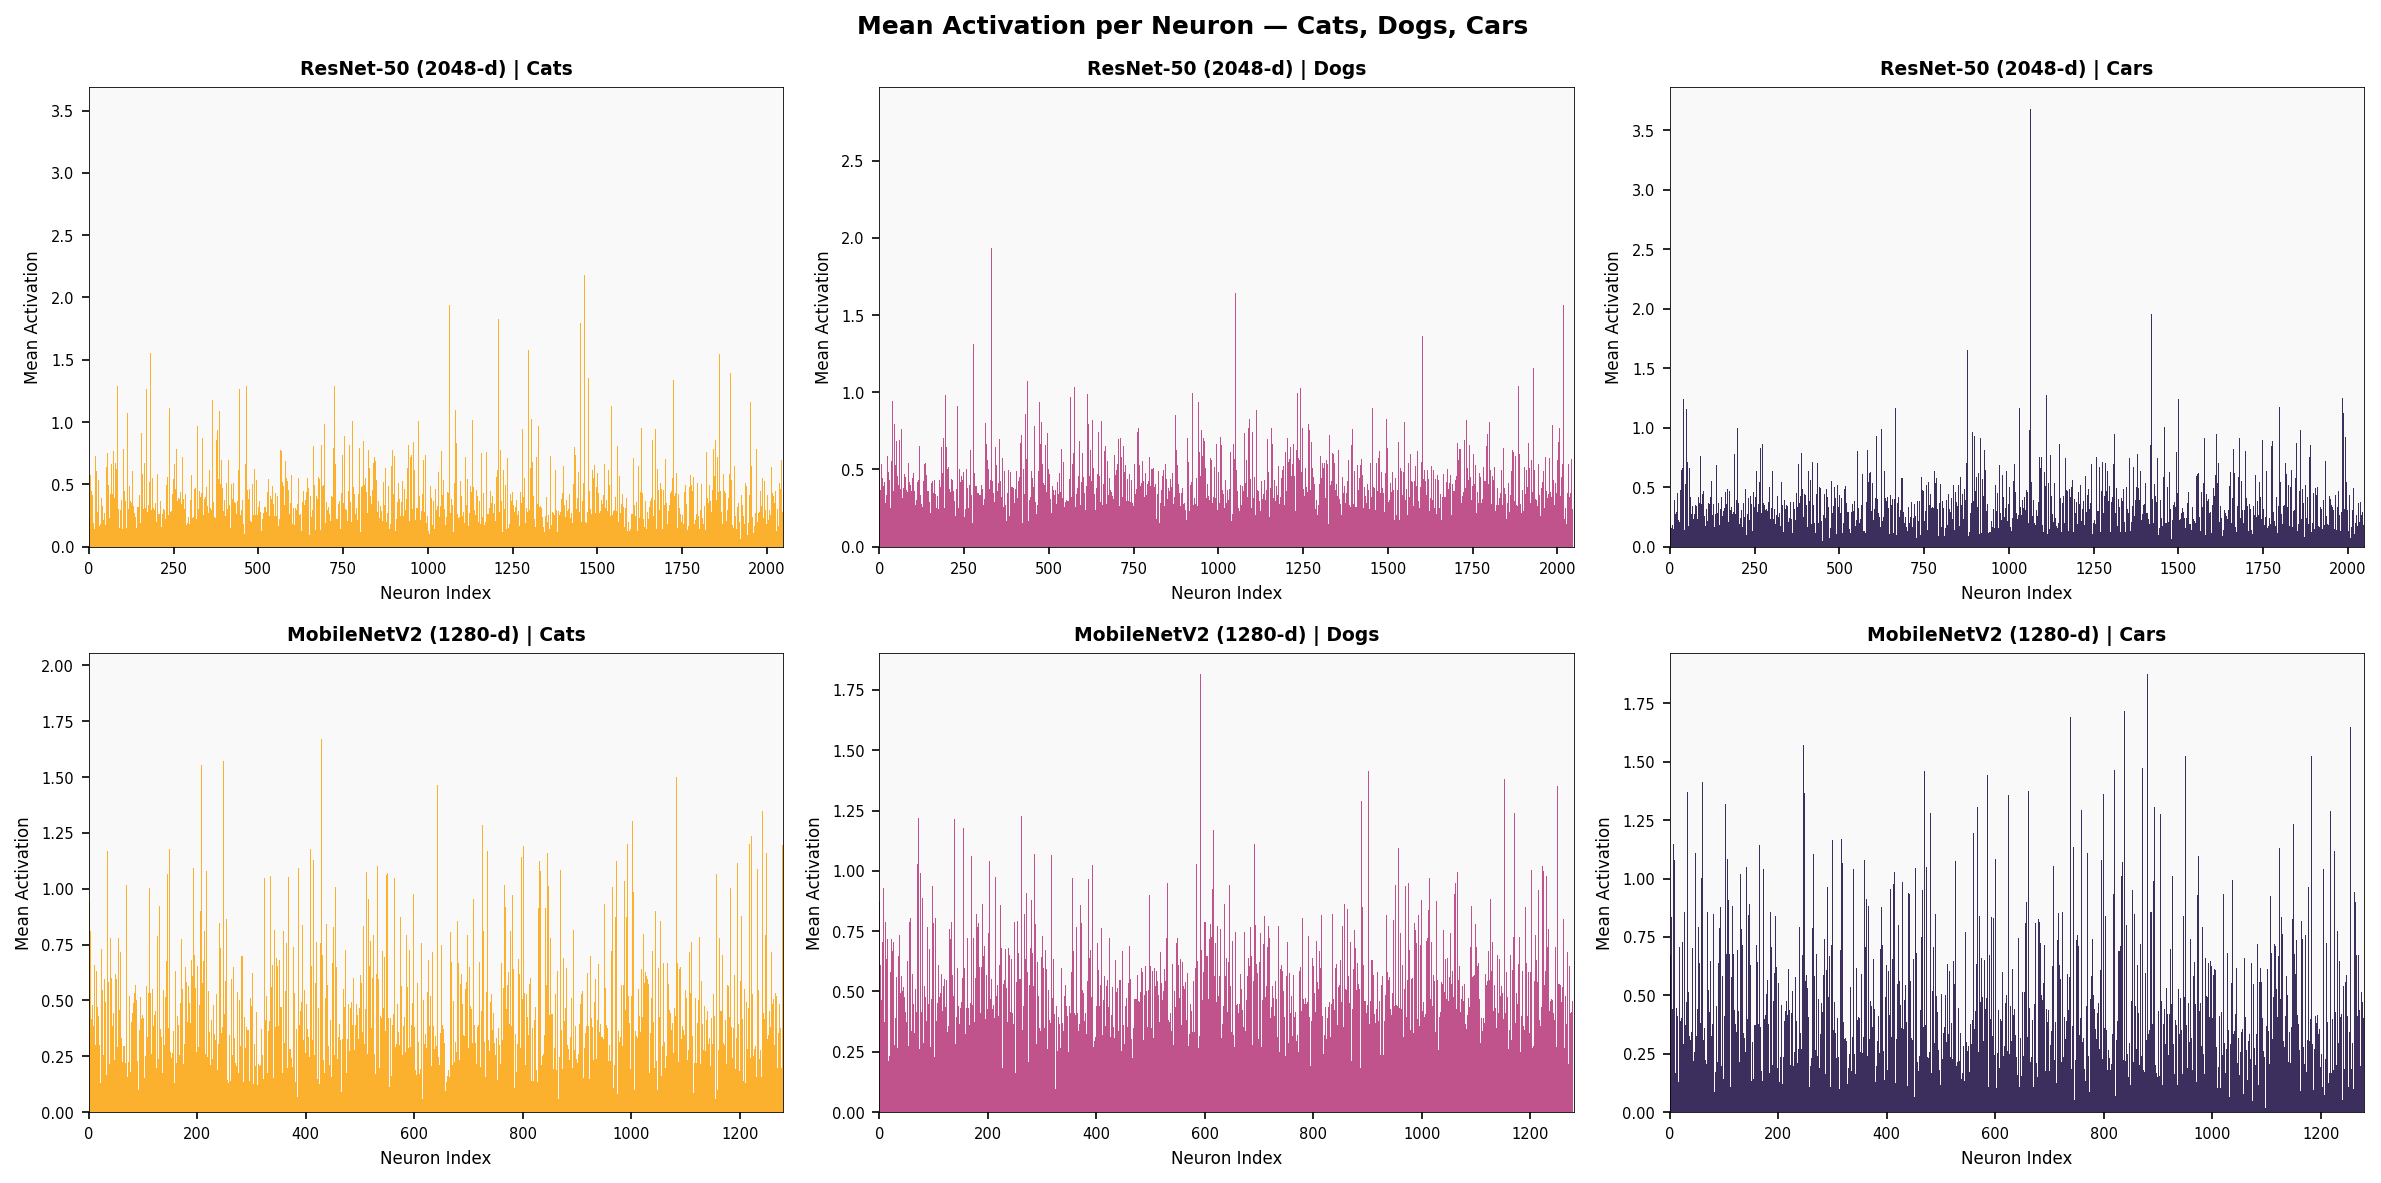


✅ Done!


In [26]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# -------- CONFIG --------
base_path = "/Users/jaeeponde/Thesis/Data_100"
target_classes = ["Cats", "Dogs", "Cars"]
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff", ".webp")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

COLOR_MAP = {
    "Cats": "#FCA50A",
    "Dogs": "#B63679",
    "Cars": "#1B0C42"
}

# -------- TRANSFORM --------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_image(path):
    return transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)

# -------- MODELS --------
print("Loading models...")
resnet = models.resnet50(pretrained=True).to(device)
resnet.eval()
resnet_extractor = nn.Sequential(*list(resnet.children())[:-1])

mobilenet = models.mobilenet_v2(pretrained=True).to(device)
mobilenet.eval()
mobilenet_extractor = nn.Sequential(
    mobilenet.features,
    nn.AdaptiveAvgPool2d((1, 1))
)
print("Models ready.\n")

def extract_features(extractor, img_tensor):
    with torch.no_grad():
        return extractor(img_tensor).view(-1).cpu().numpy()

# -------- LOAD FEATURES --------
rn_raw_list, mn_raw_list, labels_list = [], [], []

for cls in target_classes:
    cls_path = os.path.join(base_path, cls)
    images = [
        os.path.join(cls_path, f)
        for f in sorted(os.listdir(cls_path))
        if f.lower().endswith(image_extensions)
    ][:100]

    for img_path in images:
        try:
            img = load_image(img_path)
            rn_raw_list.append(extract_features(resnet_extractor, img))
            mn_raw_list.append(extract_features(mobilenet_extractor, img))
            labels_list.append(cls)
        except:
            continue

    print(f"Loaded: {cls}")

rn_raw = np.array(rn_raw_list)
mn_raw = np.array(mn_raw_list)
labels = np.array(labels_list)

print(f"\nResNet features:    {rn_raw.shape}")
print(f"MobileNet features: {mn_raw.shape}")

# ================================================================
# PLOT 1: PCA 3D
# ================================================================
pca = PCA(n_components=3)
rn_pca3 = pca.fit_transform(rn_raw)
print(f"\nResNet PCA 3D explained variance:    {pca.explained_variance_ratio_.sum():.3f}")

pca = PCA(n_components=3)
mn_pca3 = pca.fit_transform(mn_raw)
print(f"MobileNet PCA 3D explained variance: {pca.explained_variance_ratio_.sum():.3f}")

fig = plt.figure(figsize=(16, 7), dpi=150)
for idx, (coords, title) in enumerate([(rn_pca3, "ResNet-50"), (mn_pca3, "MobileNetV2")]):
    ax = fig.add_subplot(1, 2, idx + 1, projection='3d')
    for cls in target_classes:
        mask = labels == cls
        ax.scatter(coords[mask, 0], coords[mask, 1], coords[mask, 2],
                   label=cls, color=COLOR_MAP[cls],
                   alpha=0.8, s=25, edgecolors='none')
    ax.set_title(f"{title} | PCA 3D", fontsize=11, fontweight='bold')
    ax.set_xlabel("PC1", fontsize=8)
    ax.set_ylabel("PC2", fontsize=8)
    ax.set_zlabel("PC3", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=9, markerscale=1.5)

plt.suptitle("PCA 3D — Pre-Final Layer Activations (Cats, Dogs, Cars)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("pca3d_cats_dogs_cars.png", dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# PLOT 2: ACTIVATION HISTOGRAMS
# ================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 8), dpi=150)

for col, cls in enumerate(target_classes):
    cls_mask = labels == cls
    for row, (acts, model_name) in enumerate([
        (rn_raw, "ResNet-50 (2048-d)"),
        (mn_raw, "MobileNetV2 (1280-d)")
    ]):
        ax = axes[row, col]
        mean_vec = acts[cls_mask].sum(axis=0) / 100
        ax.bar(np.arange(len(mean_vec)), mean_vec,
               color=COLOR_MAP[cls], alpha=0.85, width=1.0, edgecolor='none')
        ax.set_title(f"{model_name} | {cls}", fontsize=9, fontweight='bold')
        ax.set_xlabel("Neuron Index", fontsize=8)
        ax.set_ylabel("Mean Activation", fontsize=8)
        ax.set_xlim(0, len(mean_vec))
        ax.tick_params(labelsize=7)
        ax.set_facecolor('#f9f9f9')
        for spine in ax.spines.values():
            spine.set_linewidth(0.4)

plt.suptitle("Mean Activation per Neuron — Cats, Dogs, Cars", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("histograms_cats_dogs_cars.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Done!")

## Distance Heatmaps (Euclidean & Cosine — PCA 3D and Raw Space)

Computed via the 5-class distance notebook; cats/dogs/cars subset shown here.

Loaded: Cars
Loaded: Cats
Loaded: Dogs
Loaded: Rangoli
Loaded: Microscopy

ResNet features shape:    (500, 2048)
MobileNet features shape: (500, 1280)

ResNet PCA explained variance:    0.316
MobileNet PCA explained variance: 0.256

Computing distance matrices...
Done!


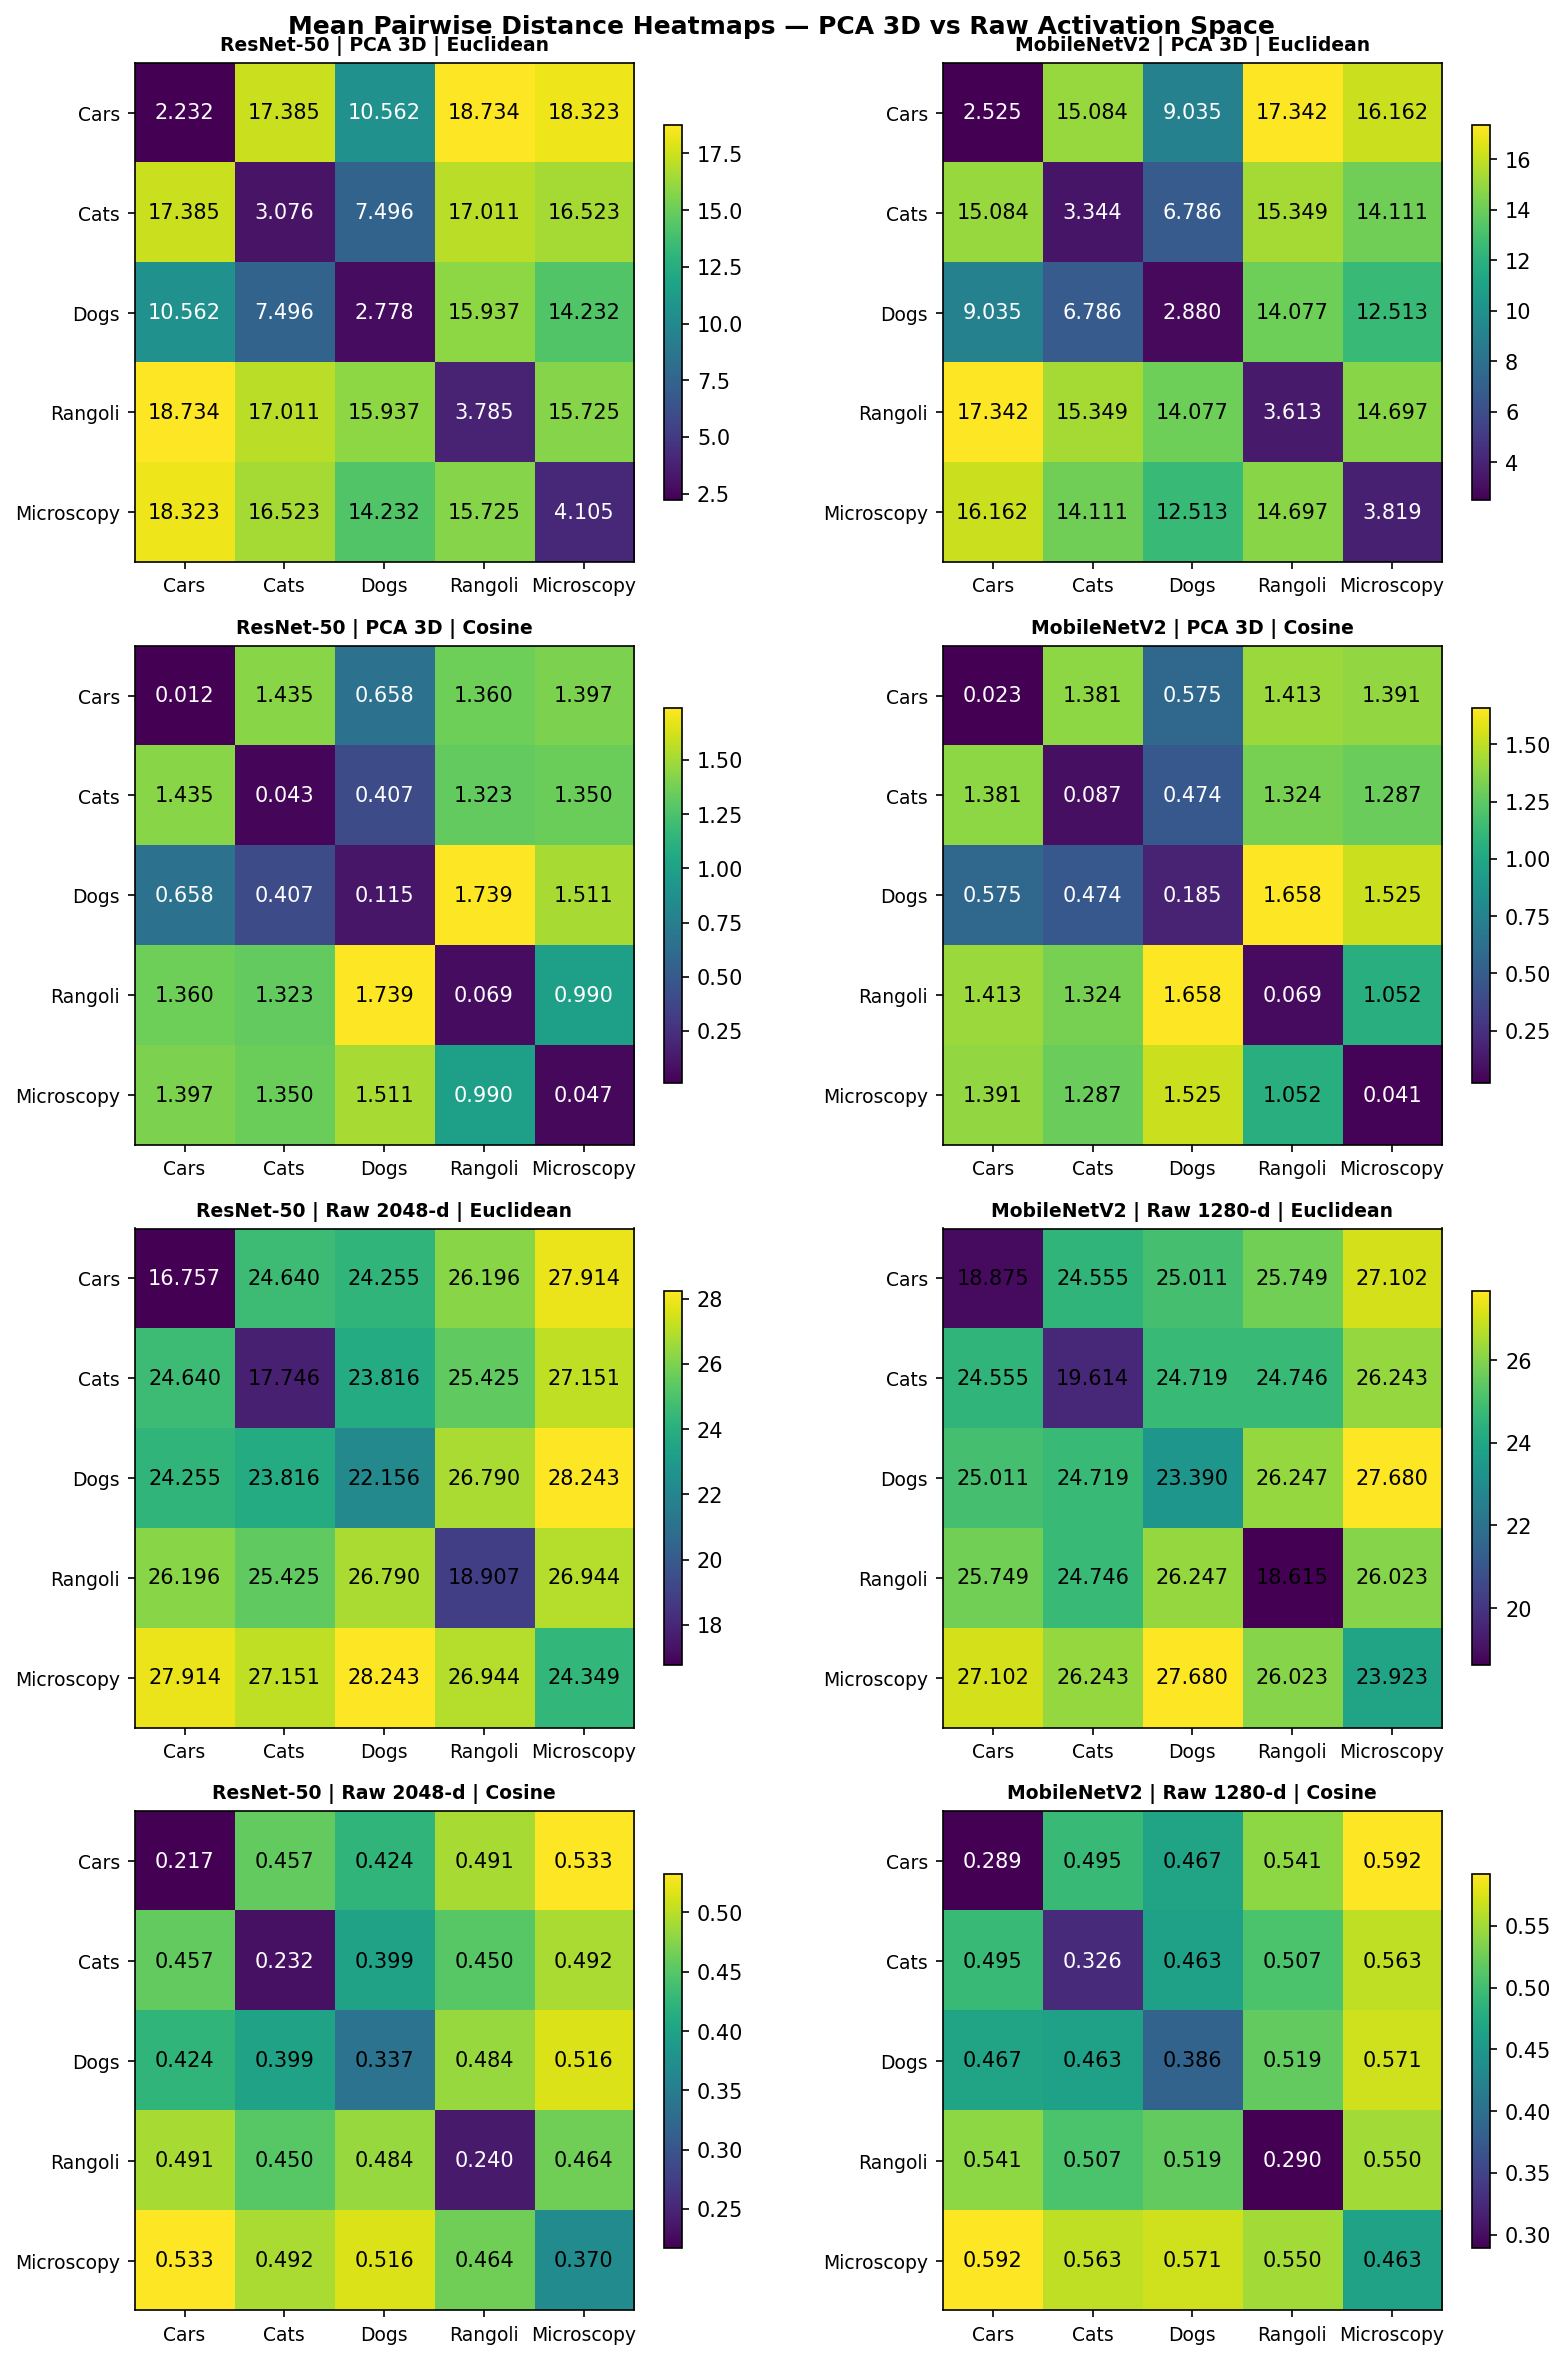

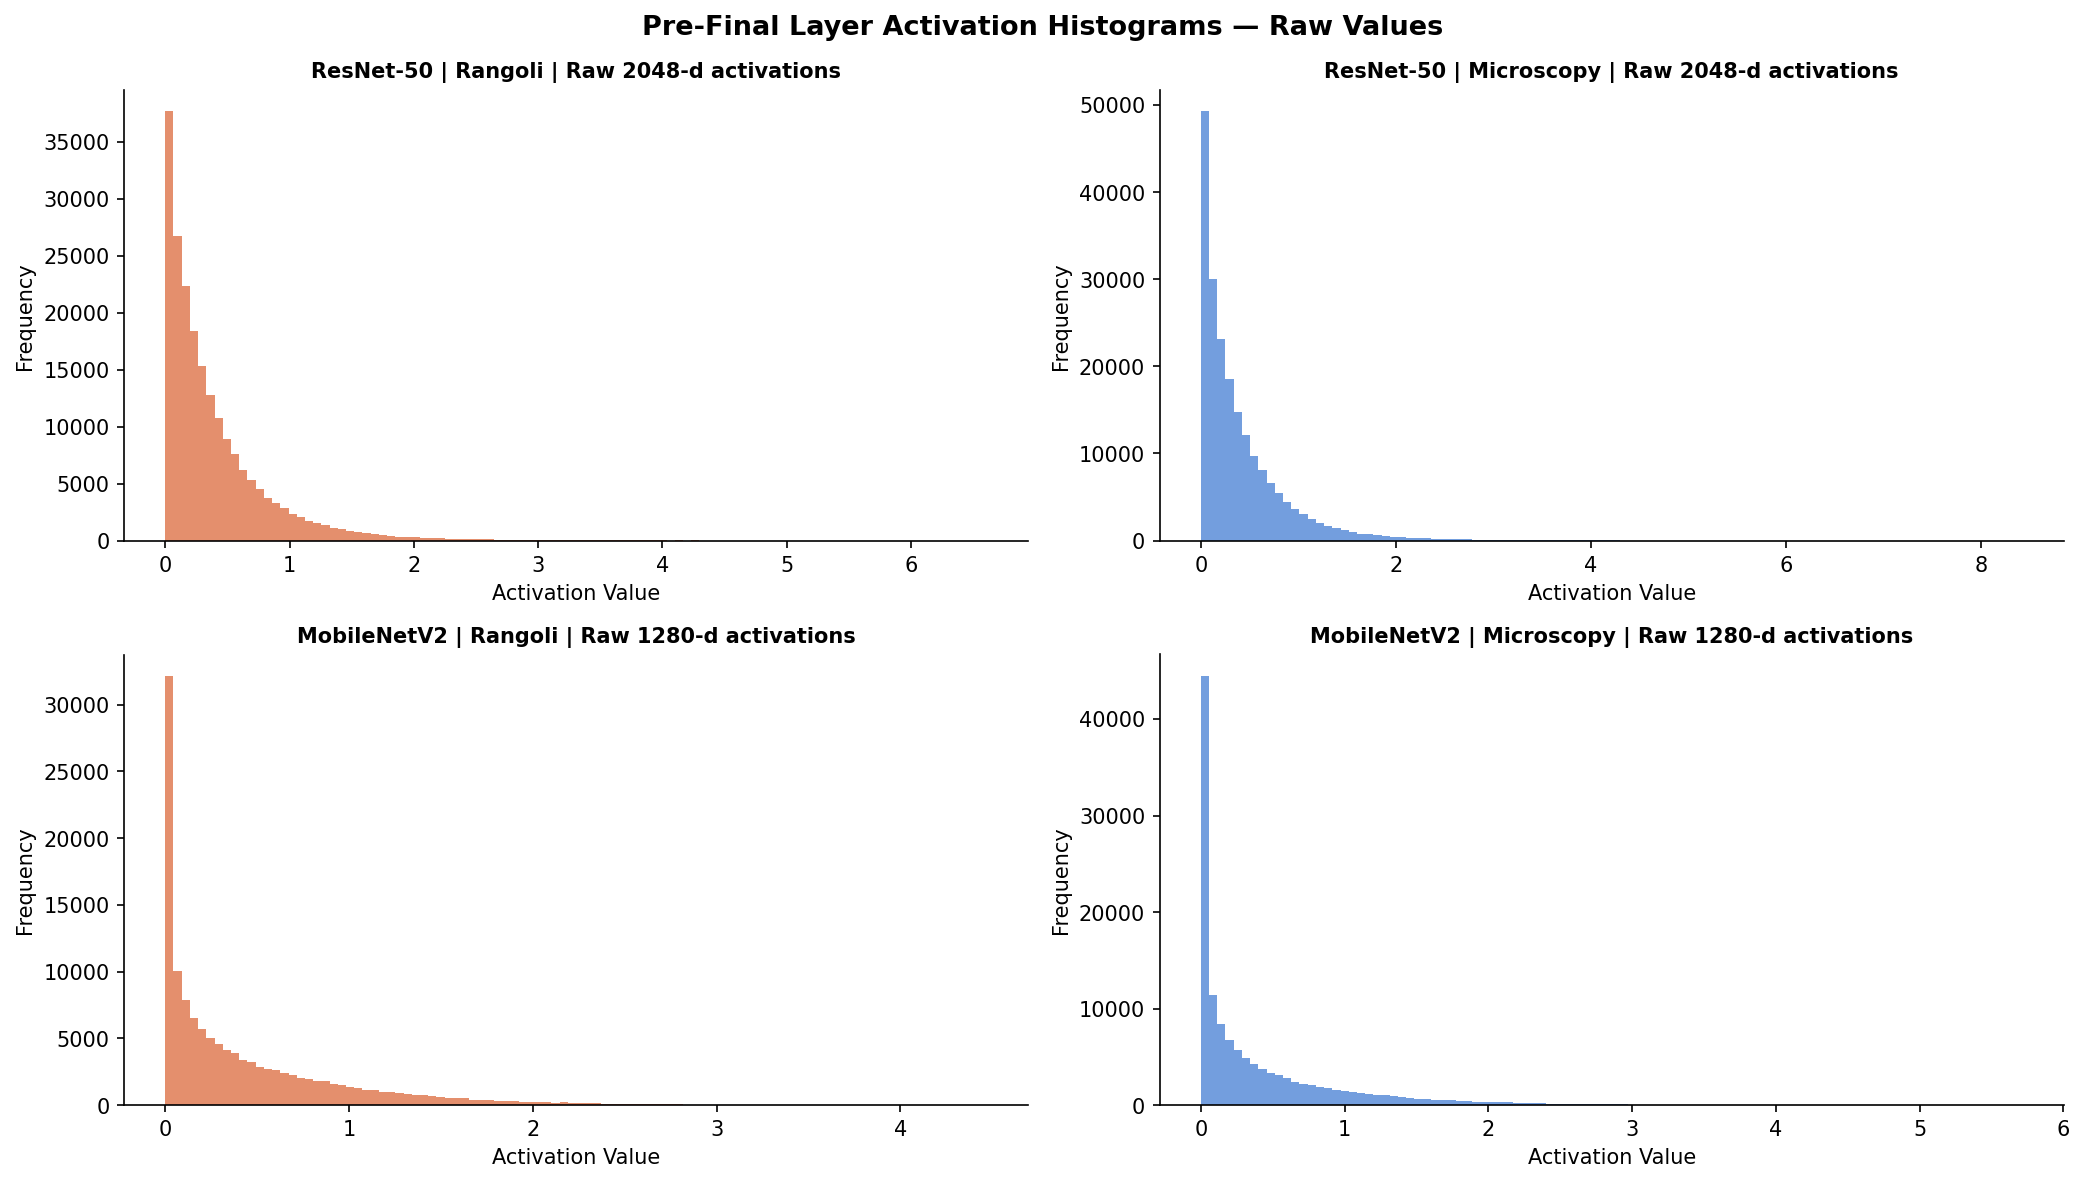

In [ ]:
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
import seaborn as sns

# -------- CONFIG --------
base_path = "/Users/jaeeponde/Thesis/Data_100"
target_classes = ["Cars", "Cats", "Dogs", "Rangoli", "Microscopy"]
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff", ".webp")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------- TRANSFORM --------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_image(path):
    return transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)

# -------- EXTRACTORS --------
resnet_full = models.resnet50(pretrained=True).to(device)
resnet_full.eval()
resnet_extractor = nn.Sequential(*list(resnet_full.children())[:-1])

mobilenet_full = models.mobilenet_v2(pretrained=True).to(device)
mobilenet_full.eval()
mobilenet_extractor = nn.Sequential(
    mobilenet_full.features,
    nn.AdaptiveAvgPool2d((1, 1))
)

def extract_features(extractor, img_tensor):
    with torch.no_grad():
        return extractor(img_tensor).view(-1).cpu().numpy()

# -------- LOAD FIRST 100 FROM EVERY CLASS --------
rn_raw_list = []
mn_raw_list = []
labels_list = []

for cls in target_classes:
    cls_path = os.path.join(base_path, cls)
    images = [
        os.path.join(cls_path, f)
        for f in sorted(os.listdir(cls_path))
        if f.lower().endswith(image_extensions)
    ][:100]

    for img_path in images:
        try:
            img = load_image(img_path)
            rn_raw_list.append(extract_features(resnet_extractor, img))
            mn_raw_list.append(extract_features(mobilenet_extractor, img))
            labels_list.append(cls)
        except:
            continue

    print(f"Loaded: {cls}")

rn_raw = np.array(rn_raw_list)
mn_raw = np.array(mn_raw_list)
labels = np.array(labels_list)

print(f"\nResNet features shape:    {rn_raw.shape}")
print(f"MobileNet features shape: {mn_raw.shape}")

# -------- PCA 3D --------
pca = PCA(n_components=3)
rn_prefinal_coords = pca.fit_transform(rn_raw)
print(f"\nResNet PCA explained variance:    {pca.explained_variance_ratio_.sum():.3f}")

pca = PCA(n_components=3)
mn_prefinal_coords = pca.fit_transform(mn_raw)
print(f"MobileNet PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# -------- DISTANCE MATRIX BUILDER --------
def build_distance_matrix(acts, labels, classes, metric):
    n   = len(classes)
    mat = np.zeros((n, n))
    for i, cls_i in enumerate(classes):
        for j, cls_j in enumerate(classes):
            pts_i     = acts[labels == cls_i]
            pts_j     = acts[labels == cls_j]
            mat[i, j] = cdist(pts_i, pts_j, metric=metric).mean()
    return mat

# -------- COMPUTE ALL 8 MATRICES --------
print("\nComputing distance matrices...")
rn_pca_euc = build_distance_matrix(rn_prefinal_coords, labels, target_classes, 'euclidean')
rn_pca_cos = build_distance_matrix(rn_prefinal_coords, labels, target_classes, 'cosine')
mn_pca_euc = build_distance_matrix(mn_prefinal_coords, labels, target_classes, 'euclidean')
mn_pca_cos = build_distance_matrix(mn_prefinal_coords, labels, target_classes, 'cosine')

rn_raw_euc = build_distance_matrix(rn_raw, labels, target_classes, 'euclidean')
rn_raw_cos = build_distance_matrix(rn_raw, labels, target_classes, 'cosine')
mn_raw_euc = build_distance_matrix(mn_raw, labels, target_classes, 'euclidean')
mn_raw_cos = build_distance_matrix(mn_raw, labels, target_classes, 'cosine')
print("Done!")

# -------- PLOT 1: DISTANCE HEATMAPS --------
fig, axes = plt.subplots(4, 2, figsize=(11, 16), dpi=150)

plot_configs = [
    (axes[0, 0], rn_pca_euc, "ResNet-50 | PCA 3D | Euclidean"),
    (axes[0, 1], mn_pca_euc, "MobileNetV2 | PCA 3D | Euclidean"),
    (axes[1, 0], rn_pca_cos, "ResNet-50 | PCA 3D | Cosine"),
    (axes[1, 1], mn_pca_cos, "MobileNetV2 | PCA 3D | Cosine"),
    (axes[2, 0], rn_raw_euc, "ResNet-50 | Raw 2048-d | Euclidean"),
    (axes[2, 1], mn_raw_euc, "MobileNetV2 | Raw 1280-d | Euclidean"),
    (axes[3, 0], rn_raw_cos, "ResNet-50 | Raw 2048-d | Cosine"),
    (axes[3, 1], mn_raw_cos, "MobileNetV2 | Raw 1280-d | Cosine"),
]

for ax, mat, title in plot_configs:
    im = ax.imshow(mat, cmap='viridis')
    for i in range(len(target_classes)):
        for j in range(len(target_classes)):
            ax.text(j, i, f"{mat[i, j]:.3f}",
                    ha='center', va='center', fontsize=10,
                    color='white' if mat[i, j] < mat.max() * 0.6 else 'black')
    ax.set_xticks(range(len(target_classes)))
    ax.set_yticks(range(len(target_classes)))
    ax.set_xticklabels(target_classes, fontsize=9)
    ax.set_yticklabels(target_classes, fontsize=9)
    ax.set_title(title, fontsize=9, fontweight='bold')
    fig.colorbar(im, ax=ax, shrink=0.75, pad=0.04)

plt.suptitle("Mean Pairwise Distance Heatmaps — PCA 3D vs Raw Activation Space",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("distance_heatmaps_pca_raw.png", dpi=150, bbox_inches='tight')
plt.show()

# -------- PLOT 2: ACTIVATION HISTOGRAMS --------
classes_to_plot = ["Rangoli", "Microscopy"]
colors = {"Rangoli": "#e07b54", "Microscopy": "#5b8dd9"}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), dpi=150)

for col, cls in enumerate(classes_to_plot):
    cls_mask = labels == cls

    rn_cls = rn_raw[cls_mask].flatten()
    mn_cls = mn_raw[cls_mask].flatten()

    axes[0, col].hist(rn_cls, bins=100, color=colors[cls], alpha=0.85, edgecolor='none')
    axes[0, col].set_title(f"ResNet-50 | {cls} | Raw 2048-d activations", fontsize=10, fontweight='bold')
    axes[0, col].set_xlabel("Activation Value")
    axes[0, col].set_ylabel("Frequency")
    sns.despine(ax=axes[0, col])

    axes[1, col].hist(mn_cls, bins=100, color=colors[cls], alpha=0.85, edgecolor='none')
    axes[1, col].set_title(f"MobileNetV2 | {cls} | Raw 1280-d activations", fontsize=10, fontweight='bold')
    axes[1, col].set_xlabel("Activation Value")
    axes[1, col].set_ylabel("Frequency")
    sns.despine(ax=axes[1, col])

plt.suptitle("Pre-Final Layer Activation Histograms — Raw Values", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("activation_histograms.png", dpi=150, bbox_inches='tight')
plt.show()

## Mahalanobis Distance — Cats, Dogs, Cars

In [48]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [49]:
def load_images_from_folder(folder_path, n=100, img_size=224):
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    images = []
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_exts)][:n]
    
    for fname in files:
        try:
            img = Image.open(os.path.join(folder_path, fname)).convert('RGB')
            images.append(transform(img))
        except Exception as e:
            print(f"Skipping {fname}: {e}")
    
    print(f"Loaded {len(images)} images from {folder_path}")
    return torch.stack(images) if images else None

In [50]:
def build_resnet_with_hook():
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.eval().to(device)
    activations = {}

    def hook_fn(module, input, output):
        activations['pre_final'] = output.detach().cpu().numpy()

    # Hook on avgpool (pre-final layer, before the FC head)
    model.avgpool.register_forward_hook(hook_fn)
    return model, activations

def build_mobilenet_with_hook():
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    model.eval().to(device)
    activations = {}

    def hook_fn(module, input, output):
        activations['pre_final'] = output.detach().cpu().numpy()

    # Hook on the adaptive avg pool (pre-final layer)
    model.features.register_forward_hook(hook_fn)
    return model, activations

resnet_model, resnet_acts = build_resnet_with_hook()
mobilenet_model, mobilenet_acts = build_mobilenet_with_hook()
print("Models ready.")

Models ready.


In [51]:
def extract_activations(model, activations_dict, image_tensor, batch_size=16):
    all_acts = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(image_tensor), batch_size):
            batch = image_tensor[i:i+batch_size].to(device)
            _ = model(batch)
            act = activations_dict['pre_final']
            # Flatten spatial dims if needed
            act = act.reshape(act.shape[0], -1)
            all_acts.append(act)
    return np.vstack(all_acts)

In [52]:
DATA_ROOT = "/Users/jaeeponde/Thesis/Data_100"  # <-- adjust path if needed
data_folders = {
    "Cats":        os.path.join(DATA_ROOT, "Cats"),
    "Dogs":        os.path.join(DATA_ROOT, "Dogs"),
    "Cars":        os.path.join(DATA_ROOT, "Cars"),
    "Rangoli":     os.path.join(DATA_ROOT, "Rangoli"),
    "Microscopy":  os.path.join(DATA_ROOT, "Microscopy"),
}

data_tensors = {}
for name, path in data_folders.items():
    data_tensors[name] = load_images_from_folder(path, n=200)

Loaded 200 images from /Users/jaeeponde/Thesis/Data_100/Cats
Loaded 200 images from /Users/jaeeponde/Thesis/Data_100/Dogs
Loaded 200 images from /Users/jaeeponde/Thesis/Data_100/Cars
Loaded 200 images from /Users/jaeeponde/Thesis/Data_100/Rangoli
Loaded 200 images from /Users/jaeeponde/Thesis/Data_100/Microscopy


In [53]:
POSE_ROOT = "/Users/jaeeponde/Thesis/Data/All_images/Pose_100"  # <-- adjust path if needed
pose_folders = {
    "Sleeping": os.path.join(POSE_ROOT, "sleeping"),
    "Standing": os.path.join(POSE_ROOT, "standing"),
}

pose_tensors = {}
for name, path in pose_folders.items():
    pose_tensors[name] = load_images_from_folder(path, n=100)

Loaded 100 images from /Users/jaeeponde/Thesis/Data/All_images/Pose_100/sleeping
Loaded 100 images from /Users/jaeeponde/Thesis/Data/All_images/Pose_100/standing


In [54]:
# Data_100 activations
resnet_data_acts  = {}
mobilenet_data_acts = {}

for name, tensor in data_tensors.items():
    if tensor is not None:
        print(f"Extracting ResNet  activations: {name}")
        resnet_data_acts[name]    = extract_activations(resnet_model,    resnet_acts,    tensor)
        print(f"Extracting MobileNet activations: {name}")
        mobilenet_data_acts[name] = extract_activations(mobilenet_model, mobilenet_acts, tensor)

# Pose_100 activations (ResNet only for bar plot 5 & 6, but we'll do both)
resnet_pose_acts    = {}
mobilenet_pose_acts = {}

for name, tensor in pose_tensors.items():
    if tensor is not None:
        print(f"Extracting ResNet  activations: {name}")
        resnet_pose_acts[name]    = extract_activations(resnet_model,    resnet_acts,    tensor)
        print(f"Extracting MobileNet activations: {name}")
        mobilenet_pose_acts[name] = extract_activations(mobilenet_model, mobilenet_acts, tensor)

print("All activations extracted!")

Extracting ResNet  activations: Cats
Extracting MobileNet activations: Cats
Extracting ResNet  activations: Dogs
Extracting MobileNet activations: Dogs
Extracting ResNet  activations: Cars
Extracting MobileNet activations: Cars
Extracting ResNet  activations: Rangoli
Extracting MobileNet activations: Rangoli
Extracting ResNet  activations: Microscopy
Extracting MobileNet activations: Microscopy
Extracting ResNet  activations: Sleeping
Extracting MobileNet activations: Sleeping
Extracting ResNet  activations: Standing
Extracting MobileNet activations: Standing
All activations extracted!


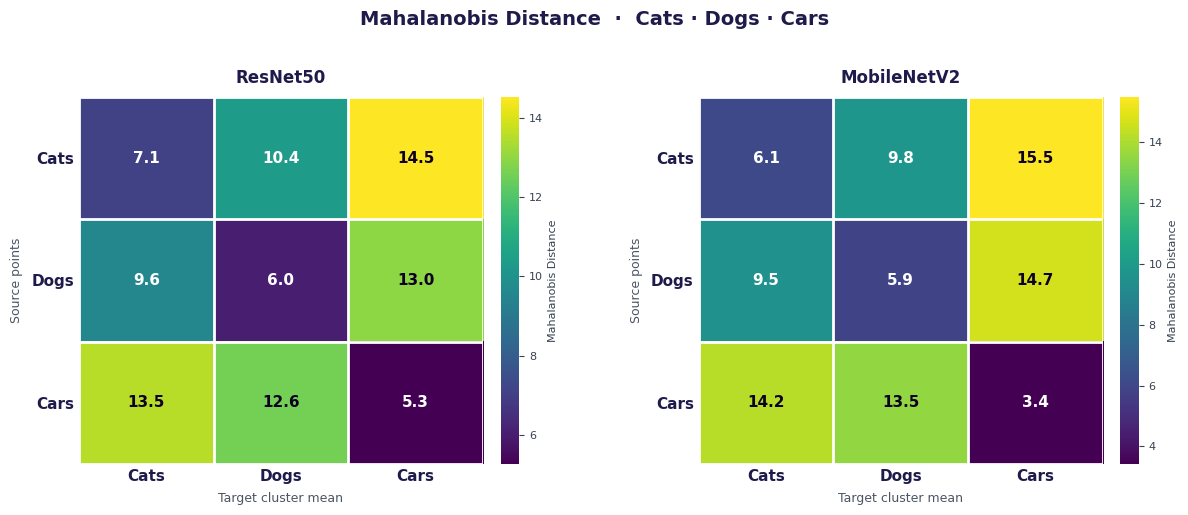

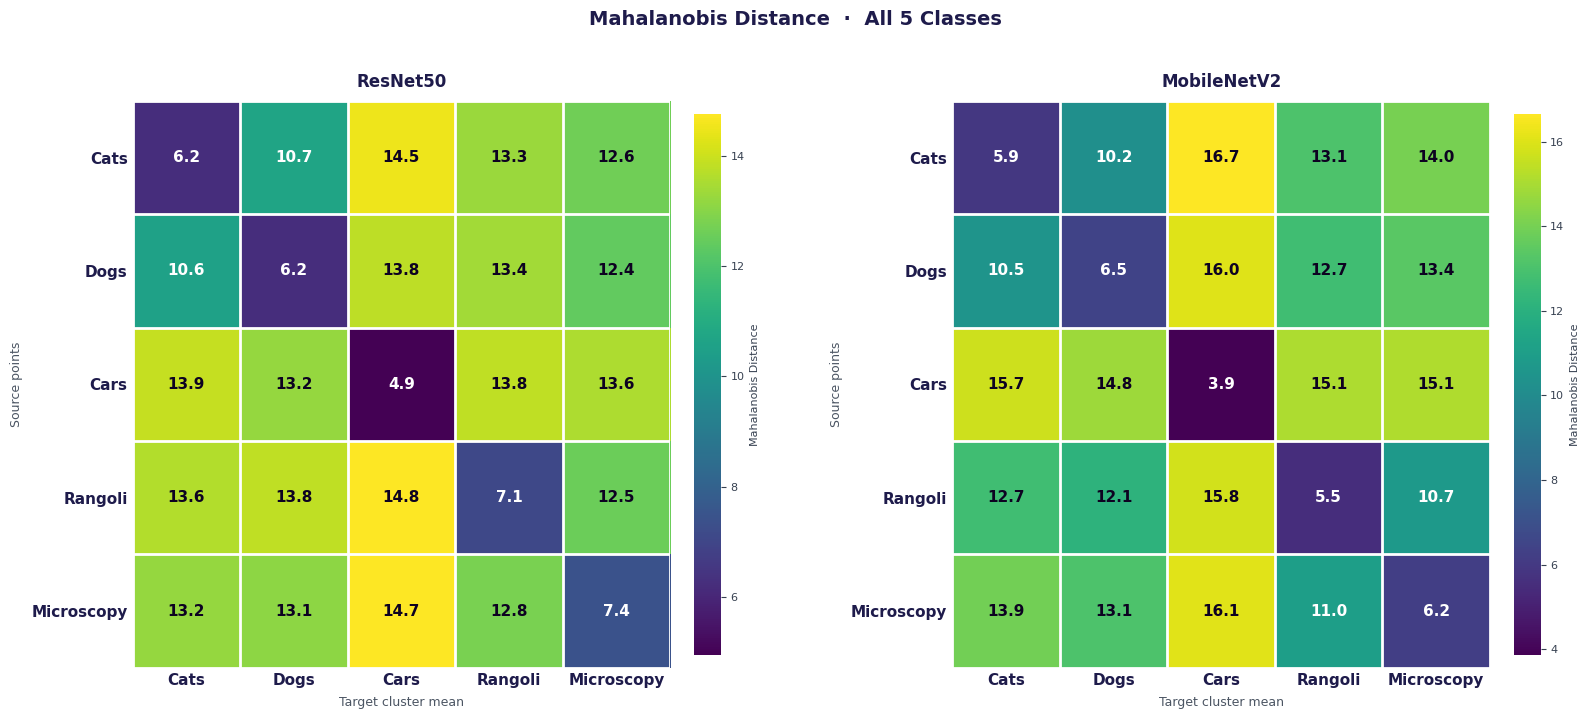

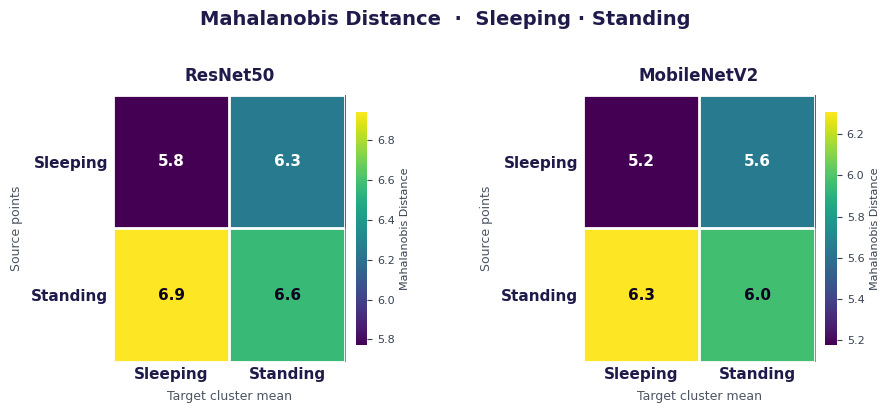

Saved → mahal1_cats_dogs_cars.png
        mahal2_all5.png
        mahal3_pose.png


In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import mahalanobis

def pointwise_mahal_matrix(acts_dict, keys, n_components=50):
    X_all = np.vstack([acts_dict[k] for k in keys])
    X_all = StandardScaler().fit_transform(X_all)
    n_comp = min(n_components, X_all.shape[0] - 1, X_all.shape[1])
    X_all  = PCA(n_components=n_comp).fit_transform(X_all)

    normed, idx = {}, 0
    for k in keys:
        n = len(acts_dict[k])
        normed[k] = X_all[idx:idx+n]
        idx += n

    n_total = len(X_all)
    pooled_cov = sum(
        np.cov(normed[k].T) * (len(normed[k]) - 1) for k in keys
    ) / (n_total - len(keys))
    pooled_cov += np.eye(pooled_cov.shape[0]) * 1e-6
    VI = np.linalg.inv(pooled_cov)

    n = len(keys)
    D = np.zeros((n, n))
    for i, src in enumerate(keys):
        for j, tgt in enumerate(keys):
            mu_tgt = normed[tgt].mean(axis=0)
            D[i, j] = np.mean([mahalanobis(x, mu_tgt, VI) for x in normed[src]])
    return D


def plot_mahal(ax, D, keys, title):
    n = len(keys)

    im = ax.imshow(D, cmap='viridis', aspect='auto',
                   vmin=D.min(), vmax=D.max(), interpolation='nearest')

    # Annotate every cell
    vrange = D.max() - D.min()
    for i in range(n):
        for j in range(n):
            val      = D[i, j]
            norm_val = (val - D.min()) / (vrange + 1e-9)
            color    = 'white' if norm_val < 0.6 else '#0d0221'
            ax.text(j, i, f"{val:.1f}",
                    ha='center', va='center',
                    fontsize=11, fontweight='bold', color=color)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(keys, fontsize=11, color='#1e1b4b', fontweight='semibold')
    ax.set_yticklabels(keys, fontsize=11, color='#1e1b4b', fontweight='semibold')
    ax.tick_params(length=0)
    ax.set_xlabel("Target cluster mean", fontsize=9, color='#4b5563', labelpad=6)
    ax.set_ylabel("Source points",       fontsize=9, color='#4b5563', labelpad=6)
    ax.set_title(title, fontsize=12, fontweight='bold', color='#1e1b4b', pad=10)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8, colors='#374151')
    cbar.set_label("Mahalanobis Distance", fontsize=8, color='#374151')
    cbar.outline.set_linewidth(0)

    # Clean cell borders
    for x in np.arange(-0.5, n, 1):
        ax.axhline(x, color='white', linewidth=2)
        ax.axvline(x, color='white', linewidth=2)

    for spine in ax.spines.values():
        spine.set_visible(False)


# ── Group definitions ──────────────────────────────────────────────────────
cats_dogs_cars = ["Cats", "Dogs", "Cars"]
all_five       = ["Cats", "Dogs", "Cars", "Rangoli", "Microscopy"]
pose_classes   = ["Sleeping", "Standing"]

SAVE_KW = dict(dpi=200, bbox_inches='tight', facecolor='white')

# ── Plot 1 : Cats · Dogs · Cars ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('white')
fig.suptitle("Mahalanobis Distance  ·  Cats · Dogs · Cars",
             fontsize=14, fontweight='bold', color='#1e1b4b', y=1.02)
plot_mahal(ax1, pointwise_mahal_matrix(resnet_data_acts,    cats_dogs_cars), cats_dogs_cars, "ResNet50")
plot_mahal(ax2, pointwise_mahal_matrix(mobilenet_data_acts, cats_dogs_cars), cats_dogs_cars, "MobileNetV2")
fig.tight_layout(w_pad=5)
fig.savefig("mahal1_cats_dogs_cars.png", **SAVE_KW)

# ── Plot 2 : All 5 Classes ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')
fig.suptitle("Mahalanobis Distance  ·  All 5 Classes",
             fontsize=14, fontweight='bold', color='#1e1b4b', y=1.02)
plot_mahal(ax1, pointwise_mahal_matrix(resnet_data_acts,    all_five), all_five, "ResNet50")
plot_mahal(ax2, pointwise_mahal_matrix(mobilenet_data_acts, all_five), all_five, "MobileNetV2")
fig.tight_layout(w_pad=5)
fig.savefig("mahal2_all5.png", **SAVE_KW)

# ── Plot 3 : Sleeping · Standing ──────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
fig.patch.set_facecolor('white')
fig.suptitle("Mahalanobis Distance  ·  Sleeping · Standing",
             fontsize=14, fontweight='bold', color='#1e1b4b', y=1.02)
plot_mahal(ax1, pointwise_mahal_matrix(resnet_pose_acts,    pose_classes), pose_classes, "ResNet50")
plot_mahal(ax2, pointwise_mahal_matrix(mobilenet_pose_acts, pose_classes), pose_classes, "MobileNetV2")
fig.tight_layout(w_pad=5)
fig.savefig("mahal3_pose.png", **SAVE_KW)

plt.show()
print("Saved → mahal1_cats_dogs_cars.png")
print("        mahal2_all5.png")
print("        mahal3_pose.png")

## Intra-Class KL Divergence — ResNet50

In [12]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
from scipy.stats import entropy

# -------- CONFIG --------
base_path = "/Users/jaeeponde/Thesis/Data_100"
num_images_avg = 100
num_images_test = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff", ".webp")

# -------- MODEL --------
resnet = models.resnet50(pretrained=True).to(device)
resnet.eval()

# penultimate layer (2048-d)
model = nn.Sequential(*list(resnet.children())[:-1])

# -------- TRANSFORM --------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def load_image(path):
    return transform(Image.open(path).convert("RGB"))

# 🔥 IMPORTANT: no probability normalization here
def get_activation(img_tensor):
    with torch.no_grad():
        feat = model(img_tensor).view(-1)

        # min-max normalize ONLY
        feat = (feat - feat.min()) / (feat.max() - feat.min() + 1e-8)

        return feat.cpu().numpy()

# -------- MAIN --------
results = {}

for subfolder in sorted(os.listdir(base_path)):
    subfolder_path = os.path.join(base_path, subfolder)
    if not os.path.isdir(subfolder_path):
        continue

    images = [
        os.path.join(subfolder_path, f)
        for f in sorted(os.listdir(subfolder_path))
        if f.lower().endswith(image_extensions)
    ]

    if len(images) < (num_images_avg + num_images_test):
        continue

    # ---------- STEP 1: AGGREGATE (first 100 images) ----------
    avg_activations = []

    for img_path in images[:num_images_avg]:
        try:
            img = load_image(img_path).unsqueeze(0).to(device)
            feat = get_activation(img)
            avg_activations.append(feat)
        except:
            continue

    avg_activations = np.stack(avg_activations)

    # 🔥 aggregate first
    avg_dist = avg_activations.mean(axis=0)

    # 🔥 normalize ONCE here
    avg_dist = avg_dist / (avg_dist.sum() + 1e-8)

    # ---------- STEP 2: KL for last 25 ----------
    kl_values = []

    for img_path in images[-num_images_test:]:
        try:
            img = load_image(img_path).unsqueeze(0).to(device)
            feat = get_activation(img)

            # 🔥 normalize ONLY here for KL
            feat = feat / (feat.sum() + 1e-8)

            kl = entropy(feat + 1e-8, avg_dist + 1e-8)
            kl_values.append(kl)

        except:
            continue

    if len(kl_values) == 0:
        continue

    avg_kl = np.mean(kl_values)
    results[subfolder] = avg_kl

    print(f"{subfolder}: Avg KL = {avg_kl:.6f}")

# -------- FINAL OUTPUT --------
print("\n=== FINAL RESULTS (ResNet50 Improved) ===")
for k, v in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{k}: {v:.6f}")

/Users/jaeeponde/anaconda3/envs/kcdha/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/jaeeponde/anaconda3/envs/kcdha/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Cars: Avg KL = 0.199026
Cats: Avg KL = 0.193674
Dogs: Avg KL = 0.250367
Memes: Avg KL = 0.263350
Microscopy: Avg KL = 0.357604
Rangoli: Avg KL = 0.383853

=== FINAL RESULTS (ResNet50 Improved) ===
Rangoli: 0.383853
Microscopy: 0.357604
Memes: 0.263350
Dogs: 0.250367
Cars: 0.199026
Cats: 0.193674


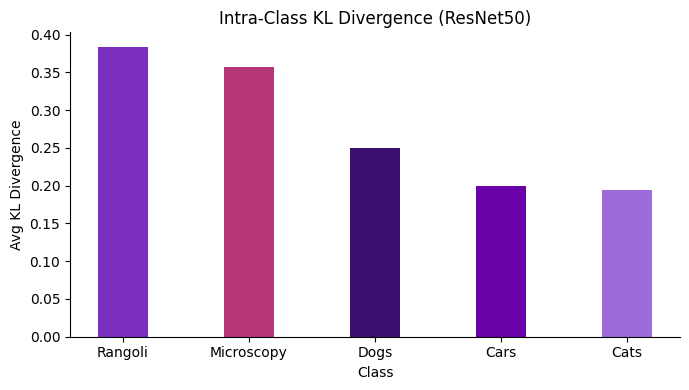

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
results_data = {
    "Rangoli": 0.383853,
    "Microscopy": 0.357604,
    "Dogs": 0.250367,
    "Cars": 0.199026,
    "Cats": 0.193674
}

colors = {"#3B0F70","#6A00A8", "#B63679", "#7B2FBE", "#9C6CDC"}

plt.figure(figsize=(7, 4))
plt.bar(results_data.keys(), results_data.values(), color=colors, width=0.4)
plt.title("Intra-Class KL Divergence (ResNet50)", fontsize=12)
plt.xlabel("Class")
plt.ylabel("Avg KL Divergence")
sns.despine()
plt.tight_layout()
plt.show()

## Cross-Class KL Divergence — ResNet50

In [14]:
# -------- CROSS-CLASS KL MATRIX (test images vs all baselines) --------
target_classes = ["Cats", "Dogs", "Cars"]

# ---------- STEP 1: Build baseline for each class (first 100) ----------
class_baselines = {}

for cls in target_classes:
    cls_path = os.path.join(base_path, cls)
    if not os.path.isdir(cls_path):
        print(f"[WARN] '{cls}' not found, skipping.")
        continue

    images = [
        os.path.join(cls_path, f)
        for f in sorted(os.listdir(cls_path))
        if f.lower().endswith(image_extensions)
    ]

    activations = []
    for img_path in images[:num_images_avg]:
        try:
            img = load_image(img_path).unsqueeze(0).to(device)
            feat = get_activation(img)
            activations.append(feat)
        except:
            continue

    if len(activations) == 0:
        continue

    avg = np.stack(activations).mean(axis=0)
    avg = avg / (avg.sum() + 1e-8)
    class_baselines[cls] = avg
    print(f"Built baseline for: {cls} ({len(activations)} images)")

# ---------- STEP 2: Test images (last 100) vs ALL baselines ----------
classes = list(class_baselines.keys())
kl_matrix = np.zeros((len(classes), len(classes)))

for i, test_cls in enumerate(classes):
    cls_path = os.path.join(base_path, test_cls)
    images = [
        os.path.join(cls_path, f)
        for f in sorted(os.listdir(cls_path))
        if f.lower().endswith(image_extensions)
    ]
    test_images = images[-num_images_test:]

    for j, baseline_cls in enumerate(classes):
        Q = class_baselines[baseline_cls]
        kl_values = []

        for img_path in test_images:
            try:
                img = load_image(img_path).unsqueeze(0).to(device)
                feat = get_activation(img)
                feat = feat / (feat.sum() + 1e-8)
                kl = entropy(feat + 1e-8, Q + 1e-8)
                kl_values.append(kl)
            except:
                continue

        kl_matrix[i][j] = np.mean(kl_values) if kl_values else np.nan

# ---------- STEP 3: Print as table ----------
import pandas as pd

df = pd.DataFrame(kl_matrix, index=classes, columns=classes)
print("\n=== CROSS-CLASS KL DIVERGENCE MATRIX ===")
print("Rows = test images source | Cols = baseline compared against")
print(df.round(4))

Built baseline for: Cats (100 images)
Built baseline for: Dogs (100 images)
Built baseline for: Cars (100 images)

=== CROSS-CLASS KL DIVERGENCE MATRIX ===
Rows = test images source | Cols = baseline compared against
        Cats    Dogs    Cars
Cats  0.1937  0.3290  0.4955
Dogs  0.4021  0.2504  0.4690
Cars  0.4852  0.3892  0.1990


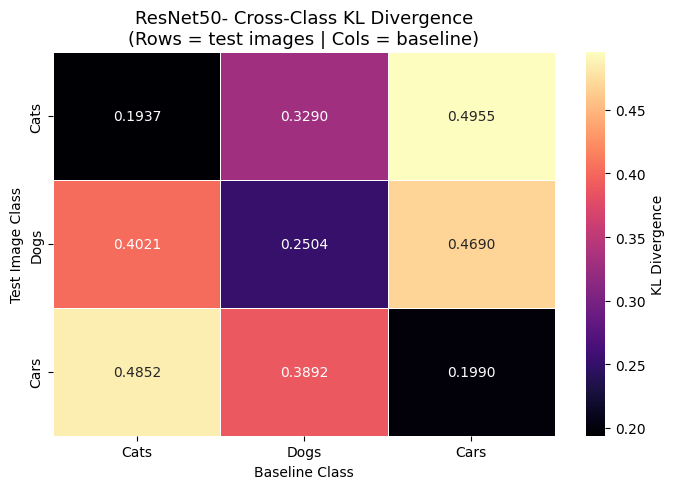

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import LinearSegmentedColormap

purple_cmap = LinearSegmentedColormap.from_list(
    "purple_indigo",
    ["#3B0F70", "#4B0082", "#6A00A8", "#7B2FBE", "#9C6CDC"]
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    df,
    annot=True,
    fmt=".4f",
    cmap="magma",
    linewidths=0.5,
    cbar_kws={"label": "KL Divergence"}
)
plt.title("ResNet50- Cross-Class KL Divergence\n(Rows = test images | Cols = baseline)", fontsize=13)
plt.xlabel("Baseline Class")
plt.ylabel("Test Image Class")
plt.tight_layout()
plt.show()

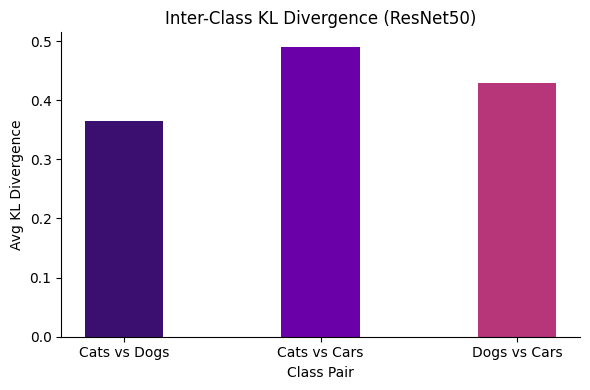

In [16]:
import itertools

pairs = list(itertools.combinations(classes, 2))
pair_labels = [f"{a} vs {b}" for a, b in pairs]
pair_kl = []

for a, b in pairs:
    i, j = classes.index(a), classes.index(b)
    # average both directions: KL(a||b) and KL(b||a)
    avg = (kl_matrix[i][j] + kl_matrix[j][i]) / 2
    pair_kl.append(avg)


#"#3B0F70","#6A00A8", "#B63679", "#7B2FBE", "#9C6CDC"

plt.figure(figsize=(6, 4))
plt.bar(pair_labels, pair_kl, color=["#3B0F70","#6A00A8", "#B63679"], width=0.4)
plt.title("Inter-Class KL Divergence (ResNet50)", fontsize=12)
plt.xlabel("Class Pair")
plt.ylabel("Avg KL Divergence")
sns.despine()
plt.tight_layout()
plt.show()

## Intra-Class KL Divergence — MobileNetV2

In [17]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
from scipy.stats import entropy

# -------- CONFIG --------
base_path = "/Users/jaeeponde/Thesis/Data_100"
num_images_avg = 100
num_images_test = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff", ".webp")

# -------- MODEL --------
model_full = models.mobilenet_v2(pretrained=True).to(device)
model_full.eval()

# penultimate layer (~1280-d)
model = nn.Sequential(
    model_full.features,
    nn.AdaptiveAvgPool2d((1, 1))
)

# -------- TRANSFORM --------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def load_image(path):
    return transform(Image.open(path).convert("RGB"))

# 🔥 IMPORTANT: no probability normalization here
def get_activation(img_tensor):
    with torch.no_grad():
        feat = model(img_tensor).view(-1)

        # min-max normalize ONLY
        feat = (feat - feat.min()) / (feat.max() - feat.min() + 1e-8)

        return feat.cpu().numpy()

# -------- MAIN --------
results = {}

for subfolder in sorted(os.listdir(base_path)):
    subfolder_path = os.path.join(base_path, subfolder)
    if not os.path.isdir(subfolder_path):
        continue

    images = [
        os.path.join(subfolder_path, f)
        for f in sorted(os.listdir(subfolder_path))
        if f.lower().endswith(image_extensions)
    ]

    if len(images) < (num_images_avg + num_images_test):
        continue

    # ---------- STEP 1: AGGREGATE (first 100 images) ----------
    avg_activations = []

    for img_path in images[:num_images_avg]:
        try:
            img = load_image(img_path).unsqueeze(0).to(device)
            feat = get_activation(img)
            avg_activations.append(feat)
        except:
            continue

    avg_activations = np.stack(avg_activations)

    # 🔥 aggregate first
    avg_dist = avg_activations.mean(axis=0)

    # 🔥 normalize ONCE here
    avg_dist = avg_dist / (avg_dist.sum() + 1e-8)

    # ---------- STEP 2: KL for last 25 ----------
    kl_values = []

    for img_path in images[-num_images_test:]:
        try:
            img = load_image(img_path).unsqueeze(0).to(device)
            feat = get_activation(img)

            # 🔥 normalize ONLY here for KL
            feat = feat / (feat.sum() + 1e-8)

            kl = entropy(feat + 1e-8, avg_dist + 1e-8)
            kl_values.append(kl)

        except:
            continue

    if len(kl_values) == 0:
        continue

    avg_kl = np.mean(kl_values)
    results[subfolder] = avg_kl

    print(f"{subfolder}: Avg KL = {avg_kl:.6f}")

# -------- FINAL OUTPUT --------
print("\n=== FINAL RESULTS (MobileNetV2 Improved) ===")
for k, v in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{k}: {v:.6f}")

/Users/jaeeponde/anaconda3/envs/kcdha/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/jaeeponde/anaconda3/envs/kcdha/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Cars: Avg KL = 0.285708
Cats: Avg KL = 0.316996
Dogs: Avg KL = 0.347401
Memes: Avg KL = 0.374124
Microscopy: Avg KL = 0.567915
Rangoli: Avg KL = 0.567002

=== FINAL RESULTS (MobileNetV2 Improved) ===
Microscopy: 0.567915
Rangoli: 0.567002
Memes: 0.374124
Dogs: 0.347401
Cats: 0.316996
Cars: 0.285708


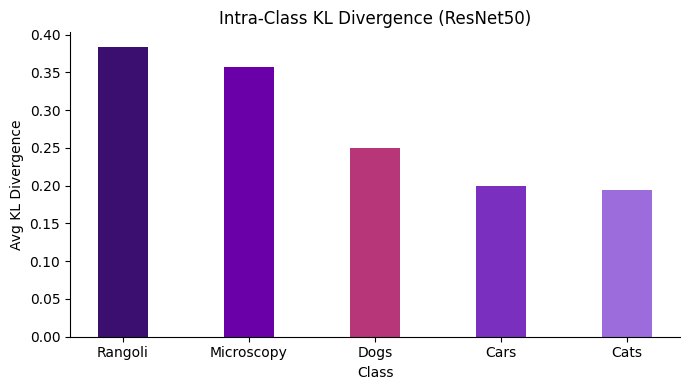

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

results_data = {
    "Rangoli": 0.383853,
    "Microscopy": 0.357604,
    "Dogs": 0.250367,
    "Cars": 0.199026,
    "Cats": 0.193674
}

colors = ["#3B0F70","#6A00A8", "#B63679", "#7B2FBE", "#9C6CDC"]

plt.figure(figsize=(7, 4))
plt.bar(results_data.keys(), results_data.values(), color=colors, width=0.4)
plt.title("Intra-Class KL Divergence (ResNet50)", fontsize=12)
plt.xlabel("Class")
plt.ylabel("Avg KL Divergence")
sns.despine()
plt.tight_layout()
plt.show()

## Cross-Class KL Divergence — MobileNetV2

Built baseline for: Cats
Built baseline for: Dogs
Built baseline for: Cars


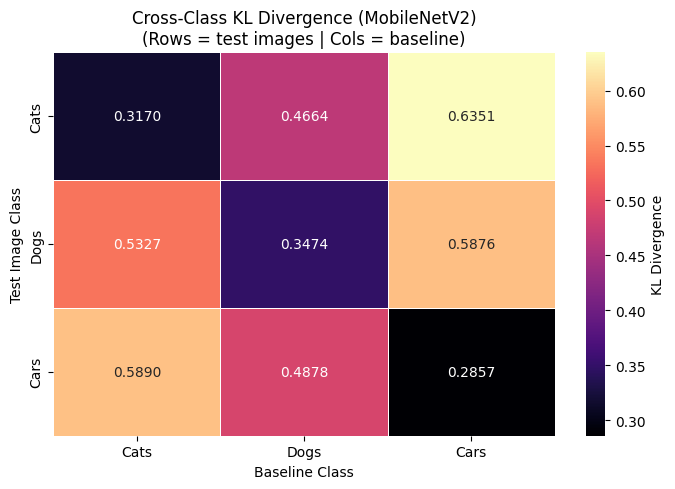

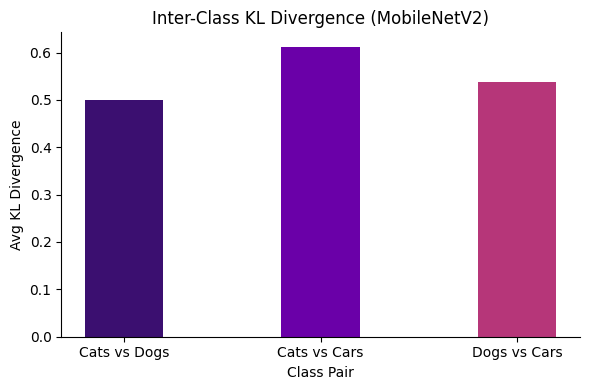

In [18]:
import itertools

target_classes = ["Cats", "Dogs", "Cars"]

# ---------- STEP 1: Build MobileNetV2 baselines (first 100) ----------
class_baselines_mobilenet = {}

for cls in target_classes:
    cls_path = os.path.join(base_path, cls)
    images = [
        os.path.join(cls_path, f)
        for f in sorted(os.listdir(cls_path))
        if f.lower().endswith(image_extensions)
    ]

    activations = []
    for img_path in images[:num_images_avg]:
        try:
            img = load_image(img_path).unsqueeze(0).to(device)
            feat = get_activation(img)
            activations.append(feat)
        except:
            continue

    avg = np.stack(activations).mean(axis=0)
    avg = avg / (avg.sum() + 1e-8)
    class_baselines_mobilenet[cls] = avg
    print(f"Built baseline for: {cls}")

# ---------- STEP 2: Test images (last 100) vs all baselines ----------
classes = list(class_baselines_mobilenet.keys())
kl_matrix = np.zeros((len(classes), len(classes)))

for i, test_cls in enumerate(classes):
    cls_path = os.path.join(base_path, test_cls)
    images = [
        os.path.join(cls_path, f)
        for f in sorted(os.listdir(cls_path))
        if f.lower().endswith(image_extensions)
    ]
    test_images = images[-num_images_test:]

    for j, baseline_cls in enumerate(classes):
        Q = class_baselines_mobilenet[baseline_cls]
        kl_values = []

        for img_path in test_images:
            try:
                img = load_image(img_path).unsqueeze(0).to(device)
                feat = get_activation(img)
                feat = feat / (feat.sum() + 1e-8)
                kl = entropy(feat + 1e-8, Q + 1e-8)
                kl_values.append(kl)
            except:
                continue

        kl_matrix[i][j] = np.mean(kl_values) if kl_values else np.nan

df_mobilenet = pd.DataFrame(kl_matrix, index=classes, columns=classes)

# ---------- STEP 3: Heatmap ----------
plt.figure(figsize=(7, 5))
sns.heatmap(df_mobilenet, annot=True, fmt=".4f", cmap="magma", linewidths=0.5, cbar_kws={"label": "KL Divergence"})
plt.title("Cross-Class KL Divergence (MobileNetV2)\n(Rows = test images | Cols = baseline)", fontsize=12)
plt.xlabel("Baseline Class")
plt.ylabel("Test Image Class")
plt.tight_layout()
plt.show()

# ---------- STEP 4: Bar plot ----------
pairs = list(itertools.combinations(classes, 2))
pair_labels = [f"{a} vs {b}" for a, b in pairs]
pair_kl = [(kl_matrix[classes.index(a)][classes.index(b)] + kl_matrix[classes.index(b)][classes.index(a)]) / 2 for a, b in pairs]

plt.figure(figsize=(6, 4))
plt.bar(pair_labels, pair_kl, color=["#3B0F70","#6A00A8", "#B63679"], width=0.4)
plt.title("Inter-Class KL Divergence (MobileNetV2)", fontsize=12)
plt.xlabel("Class Pair")
plt.ylabel("Avg KL Divergence")
sns.despine()
plt.tight_layout()
plt.show()

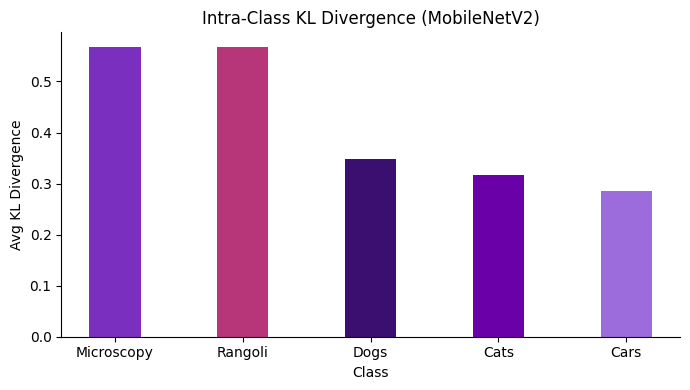

In [19]:
results_mobilenet = {
    "Microscopy": 0.567915,
    "Rangoli": 0.567002,
    "Dogs": 0.347401,
    "Cats": 0.316996,
    "Cars": 0.285708
}

colors = {"#3B0F70","#6A00A8", "#B63679", "#7B2FBE", "#9C6CDC"
}

plt.figure(figsize=(7, 4))
plt.bar(results_mobilenet.keys(), results_mobilenet.values(), color=colors, width=0.4)
plt.title("Intra-Class KL Divergence (MobileNetV2)", fontsize=12)
plt.xlabel("Class")
plt.ylabel("Avg KL Divergence")
sns.despine()
plt.tight_layout()
plt.show()